### Analysis description
Here we aim at drawing a pycortex flatmaps, create static webgl, and plot inflated brain maps.<br/>

In [1]:
# Stop warnings
import warnings
warnings.filterwarnings("ignore")

# Debug import 
import ipdb
deb = ipdb.set_trace

# General imports
import os
import sys
import cortex
import re, time
import matplotlib.pyplot as plt

# Personal imports
sys.path.append("{}/../../../../../analysis_code/utils".format(os.getcwd()))
from pycortex_utils import draw_cortex, set_pycortex_config_file, load_surface_pycortex, create_colormap
from settings_utils import load_settings


In [2]:
# Define parameters
subject = 'sub-01'
pycortex_subject = subject
project_dir = 'amblyo7T_prf'
main_dir = '/home/mszinte/disks/meso_S/data'

# Load settings
base_dir = os.path.abspath(os.path.join(os.getcwd(), "../../../../../"))
settings_path = os.path.join(base_dir, project_dir, "settings.yml")
prf_settings_path = os.path.join(base_dir, project_dir, "prf-analysis.yml")
figure_settings_path = os.path.join(base_dir, project_dir, "figure-settings.yml")
settings = load_settings([settings_path, prf_settings_path, figure_settings_path])
analysis_info = settings[0]
if subject == 'sub-170k': formats = ['170k']
else: formats = analysis_info['formats']
preproc_prep = analysis_info['preproc_prep']
filtering = analysis_info['filtering']
normalization = analysis_info['normalization']
rois_methods = analysis_info['rois_methods']
pycortex_subject_template = analysis_info['pycortex_subject_template']

# Set pycortex db and colormaps
cortex_dir = "{}/{}/derivatives/pp_data/cortex".format(main_dir, project_dir)
set_pycortex_config_file(cortex_dir)
print(cortex_dir)

# Define/create colormap
rois_colors = analysis_info['rois_colors']
colormap_name = 'rois_colors'
colormap_dict = {key: tuple(value) for key, value in rois_colors.items()}
create_colormap(cortex_dir=cortex_dir, 
                colormap_name=colormap_name, 
                colormap_dict=colormap_dict,
                recreate=True
               )

/home/mszinte/disks/meso_S/data/amblyo7T_prf/derivatives/pp_data/cortex
Saving new colormap: /home/mszinte/disks/meso_S/data/amblyo7T_prf/derivatives/pp_data/cortex/colormaps/rois_colors.png


In [3]:
format_ = 'fsnative'
rois_method_format = 'rois-group-mmp'
overlay_fn = f"overlays_{rois_method_format}.svg"

# Create flatmaps
# Define directories and fn
rois_dir = "{}/{}/derivatives/pp_data/{}/{}/rois".format(main_dir, project_dir, subject, format_)
flatmaps_dir = '{}/pycortex/flatmaps_rois'.format(rois_dir)
datasets_dir = '{}/pycortex/datasets_rois'.format(rois_dir)

In [4]:
roi_fn_L = '{}/{}_hemi-L_{}_{}_{}_{}.func.gii'.format(rois_dir, subject, 
                                                      preproc_prep, filtering, 
                                                      normalization, rois_method_format)
roi_fn_R = '{}/{}_hemi-R_{}_{}_{}_{}.func.gii'.format(rois_dir, subject,
                                                      preproc_prep, filtering, 
                                                      normalization, rois_method_format)
results = load_surface_pycortex(L_fn=roi_fn_L, R_fn=roi_fn_R)
roi_mat = results['data_concat']

Creating flatmaps...
Color map rois_colors is already registered.
Unable to init server: Could not connect: Connection refused
Failed to get connection
** (inkscape:715267): CRITICAL **: 23:34:58.606: dbus_g_proxy_new_for_name: assertion 'connection != NULL' failed
** (inkscape:715267): CRITICAL **: 23:34:58.606: dbus_g_proxy_call: assertion 'DBUS_IS_G_PROXY (proxy)' failed
** (inkscape:715267): CRITICAL **: 23:34:58.606: dbus_g_connection_register_g_object: assertion 'connection != NULL' failed
** (inkscape:715267): WARNING **: 23:34:58.881: Fonts dir '/usr/share/inkscape/fonts' does not exist and will be ignored.
** (inkscape:715267): WARNING **: 23:34:58.881: Fonts dir '/home/mszinte/.config/inkscape/fonts' does not exist and will be ignored.
Background RRGGBBAA: ffffff00
Area 0:0:2316.19:1024 exported to 2316 x 1024 pixels (96 dpi)


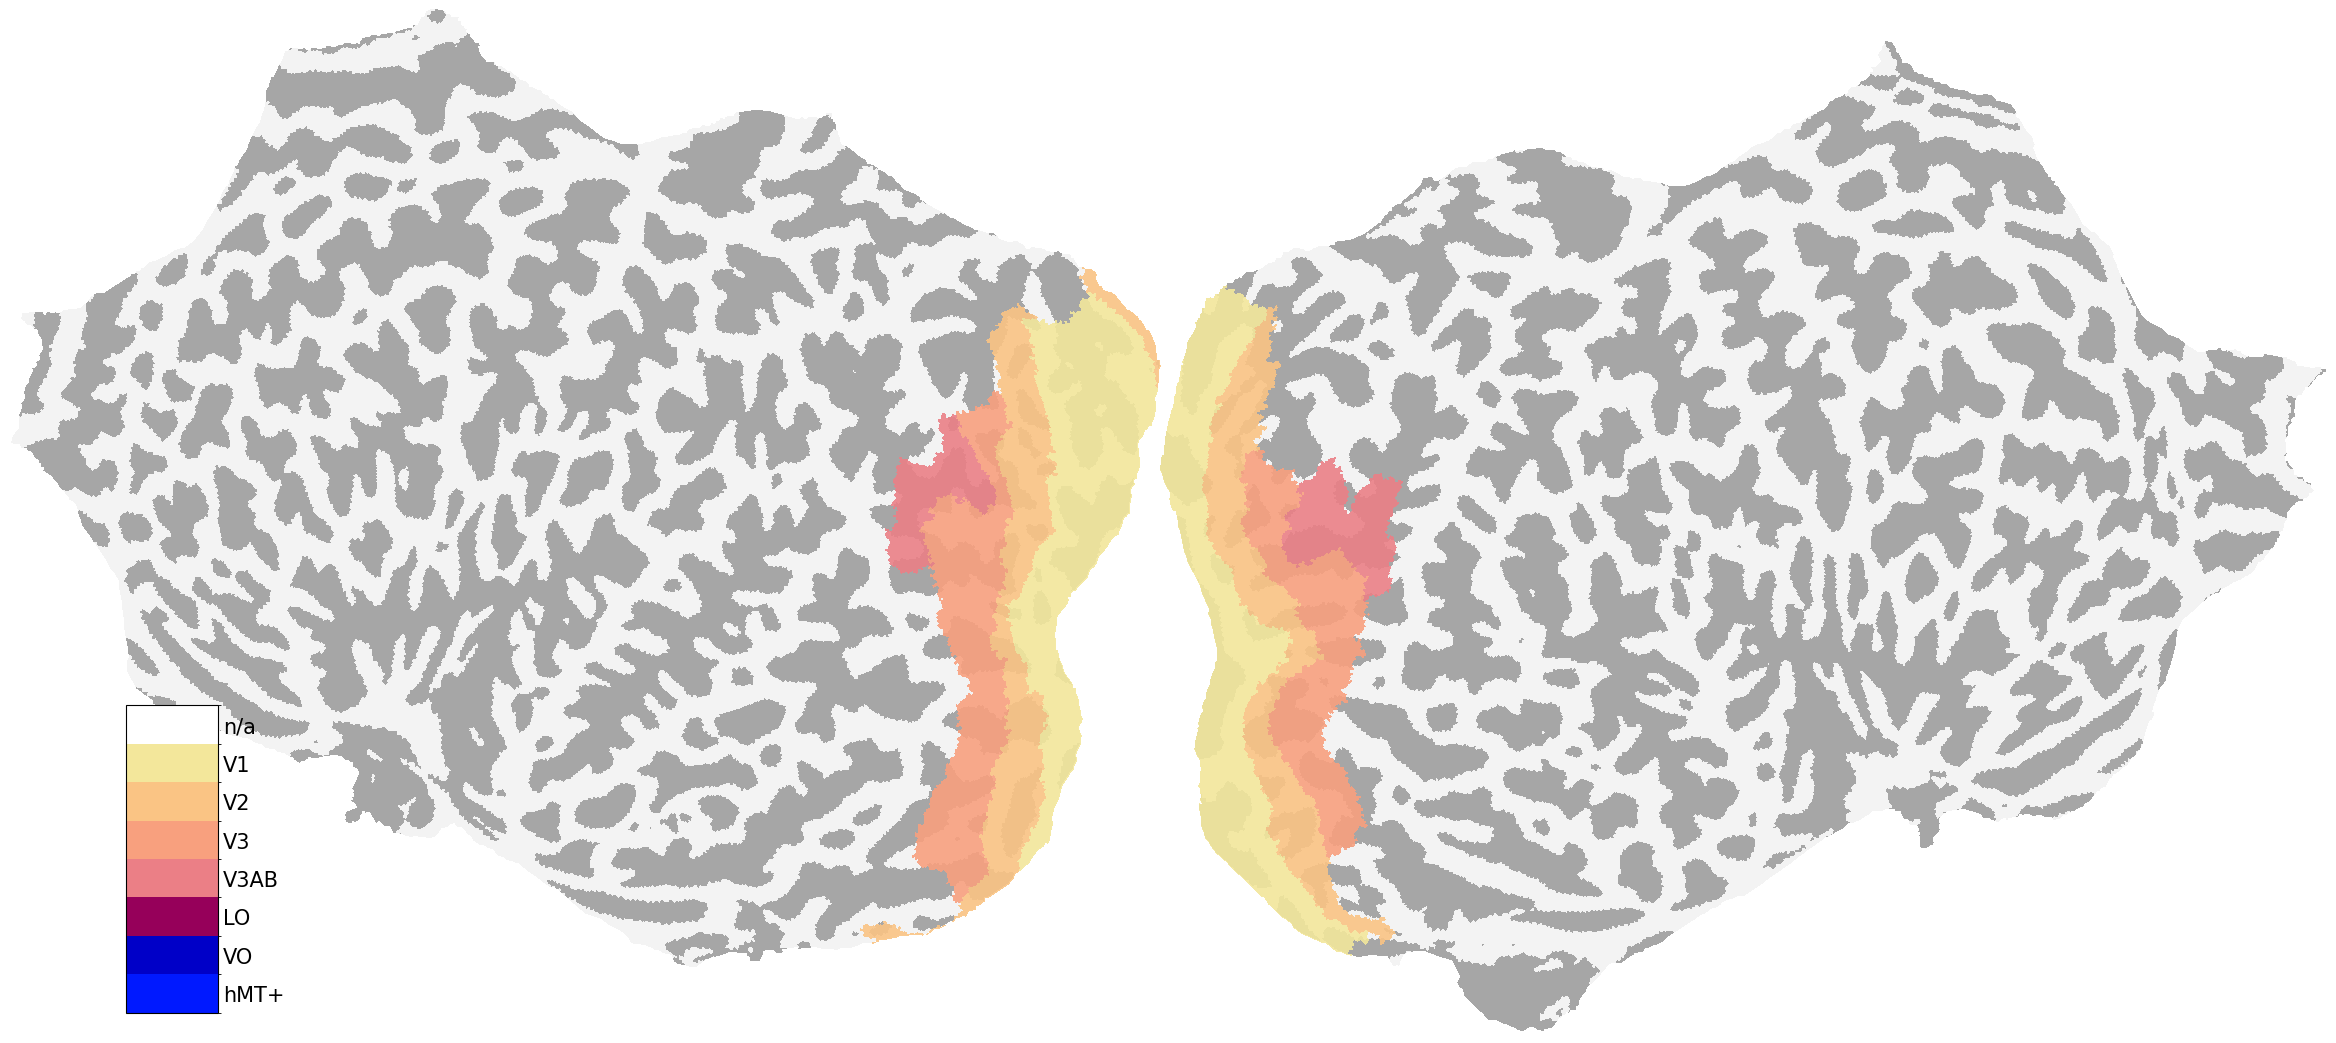

In [9]:
rois_opacity = 0.9
alpha_mat = roi_mat*0+rois_opacity
alpha_mat[roi_mat==0]=0

# Show only V1/V2/V3/V3AB
alpha_mat[roi_mat==5]=0
alpha_mat[roi_mat==6]=0
alpha_mat[roi_mat==7]=0
print('Creating flatmaps...')

# Rois
roi_name = 'rois'
param_rois = {'subject': pycortex_subject,
              'data': roi_mat, 
              'cmap': colormap_name,
              'alpha': alpha_mat,
              'cbar': 'discrete_personalized', 
              'vmin': 0,
              'vmax': len(colormap_dict),
              'cmap_steps': len(colormap_dict),
              'cmap_dict': colormap_dict,
              'cortex_type': 'VertexRGB',
              'description': 'ROIs',
              'curv_brightness': 0.8, 
              # 'overlay_fn': overlay_fn,
              'curv_contrast': 0.3,
              'add_roi': 'n',
              'with_labels': True,
              'roi_name': roi_name}
              
# Draw flatmaps
volume_roi = draw_cortex(**param_rois)
plt.savefig('{}/rois_flat.pdf'.format(os.getcwd()))

In [29]:
# Webgl for inflated brain pictures
subject2plot = 'sub-01'

port_num = 25972 # open on invibe server
print("Command to type on local terminal...")
print("ssh -Y -fN -L localhost:{}:localhost:{} admin@invibe.nohost.me".format(port_num,port_num))
print("Go to (in 5 s...): http://localhost:{}/".format(port_num))
exec('handle = cortex.webgl.show(data=volume_roi,recache = False, port=port_num, title=subject2plot, labels_visible=[True])')

Command to type on local terminal...
ssh -Y -fN -L localhost:25972:localhost:25972 admin@invibe.nohost.me
Go to (in 5 s...): http://localhost:25972/
Started server on port 25972
Stopping server


In [45]:
# general settings
set1 = {'camera.azimuth':242,
        'camera.altitude':93,
        'camera.radius':324,
        'surface.{subject}.unfold':0,
        'surface.{subject}.pivot':33,
        'surface.{subject}.left':True,
        'surface.{subject}.right':False,
        'surface.{subject}.depth':0.5,
        'surface.{subject}.specularity':0.2,
        'surface.{subject}.layers':4,
        'surface.{subject}.dither':False,
        'surface.{subject}.colorbar':False,
        'surface.{subject}.sampler':'nearest',
        'surface.{subject}.curvature.brightness':0.2,
        'surface.{subject}.curvature.contrast':0.2,
        'surface.{subject}.curvature.smoothness':0}
handle._set_view(**set1)
time.sleep(5)
handle.getImage('{}/rois_pial.png'.format(os.getcwd()),size = (3000, 3000))

In [46]:
# general settings
set2 = {'camera.azimuth':242,
        'camera.altitude':93,
        'camera.radius':324,
        'surface.{subject}.unfold':0.5,
        'surface.{subject}.pivot':33,
        'surface.{subject}.left':True,
        'surface.{subject}.right':False,
        'surface.{subject}.depth':0.5,
        'surface.{subject}.specularity':0.2,
        'surface.{subject}.layers':4,
        'surface.{subject}.dither':False,
        'surface.{subject}.colorbar':False,
        'surface.{subject}.sampler':'nearest',
        'surface.{subject}.curvature.brightness':0.2,
        'surface.{subject}.curvature.contrast':0.2,
        'surface.{subject}.curvature.smoothness':0}
handle._set_view(**set2)
time.sleep(5)
handle.getImage('{}/rois_inflated.png'.format(os.getcwd()),size = (3000, 3000))